# Notebook 01 — Spatial Setup

**Purpose:** Load the GADM India district shapefile, filter to Punjab & Haryana, apply known name fixes, save as GeoPackage, and produce a labelled boundary map.

**Input:** `data/raw/spatial/gadm41_IND.gpkg`  
**Output:** `data/processed/Punjab_Haryana_districts.gpkg`, `outputs/maps/00_district_boundaries.png`

In [22]:
import os
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#  Create required output directories 
os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs/maps',   exist_ok=True)

print("Directories ready")


✅ Directories ready


In [23]:
# Load full India GADM Level-2 (district polygons) 
print("Loading GADM India — this may take a few seconds ...")
india = gpd.read_file('../data/raw/spatial/gadm41_IND.gpkg', layer='ADM_ADM_2')

print(f"   Total India districts : {len(india)}")
print(f"   CRS                   : {india.crs}")
print(f"   Columns               : {india.columns.tolist()}")


Loading GADM India — this may take a few seconds ...
   Total India districts : 676
   CRS                   : EPSG:4326
   Columns               : ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']


In [24]:
# Filter to Punjab & Haryana 
ph = india[india['NAME_1'].isin(['Punjab', 'Haryana'])].copy()
ph = ph[['NAME_1', 'NAME_2', 'geometry']].reset_index(drop=True)

print(f"Rows after state filter: {len(ph)}")
print(ph['NAME_1'].value_counts().to_string())


Rows after state filter: 43
NAME_1
Punjab     22
Haryana    21


In [25]:
# Apply known GADM name fixes 
# GADM uses official/historical names that differ from common usage.
# These fixes align district names with the crop and fire datasets.
name_fixes = {
    'Firozpur'                   : 'Ferozepur',      # Punjab
    'Sahibzada Ajit Singh Nagar' : 'Mohali',         # Punjab
    'Shahid Bhagat Singh Nagar'  : 'Nawanshahr',     # Punjab
    'Gurgaon'                    : 'Gurugram',       # Haryana
    'Mewat'                      : 'Nuh',            # Haryana
}
ph['NAME_2'] = ph['NAME_2'].replace(name_fixes)

# Known data limitation 
# Charkhi Dadri (carved from Bhiwani in 2016) is absent in GADM 4.1.
# The Bhiwani polygon covers both areas. We retain 43 polygons and
# document this as a known limitation in the methodology.
print("NOTE: Charkhi Dadri absent in GADM — Bhiwani polygon covers both.")
print(f"   Final polygon count: {len(ph)}")


⚠  NOTE: Charkhi Dadri absent in GADM — Bhiwani polygon covers both.
   Final polygon count: 43


In [26]:
# District inventory 
print(f"{'─'*50}")
print(f"  {'STATE':<15} DISTRICTS")
print(f"{'─'*50}")
for state in ['Punjab', 'Haryana']:
    n = len(ph[ph['NAME_1'] == state])
    print(f"  {state:<15} {n}")
print(f"{'─'*50}")
print(f"  {'TOTAL':<15} {len(ph)}")
print(f"{'─'*50}")
print()
print(ph[['NAME_1', 'NAME_2']].sort_values(['NAME_1', 'NAME_2']).to_string(index=False))


──────────────────────────────────────────────────
  STATE           DISTRICTS
──────────────────────────────────────────────────
  Punjab          22
  Haryana         21
──────────────────────────────────────────────────
  TOTAL           43
──────────────────────────────────────────────────

 NAME_1          NAME_2
Haryana          Ambala
Haryana         Bhiwani
Haryana       Faridabad
Haryana       Fatehabad
Haryana        Gurugram
Haryana           Hisar
Haryana         Jhajjar
Haryana            Jind
Haryana         Kaithal
Haryana          Karnal
Haryana     Kurukshetra
Haryana    Mahendragarh
Haryana             Nuh
Haryana          Palwal
Haryana       Panchkula
Haryana         Panipat
Haryana          Rewari
Haryana          Rohtak
Haryana           Sirsa
Haryana         Sonipat
Haryana     Yamunanagar
 Punjab        Amritsar
 Punjab         Barnala
 Punjab        Bathinda
 Punjab        Faridkot
 Punjab Fatehgarh Sahib
 Punjab         Fazilka
 Punjab       Ferozepur
 Punjab 

In [27]:
# Save GeoPackage 
out_path = '../Data/Processed/Punjab_Haryana_districts.gpkg'
ph.to_file(out_path, driver='GPKG')

# Verify the saved file
verify = gpd.read_file(out_path)
assert len(verify) == len(ph), "Save verification failed — row count mismatch!"
print(f"Saved and verified: {out_path}")
print(f"   {len(verify)} polygons | Punjab 22 | Haryana 21")


✅ Saved and verified: ../Data/Processed/Punjab_Haryana_districts.gpkg
   43 polygons | Punjab 22 | Haryana 21


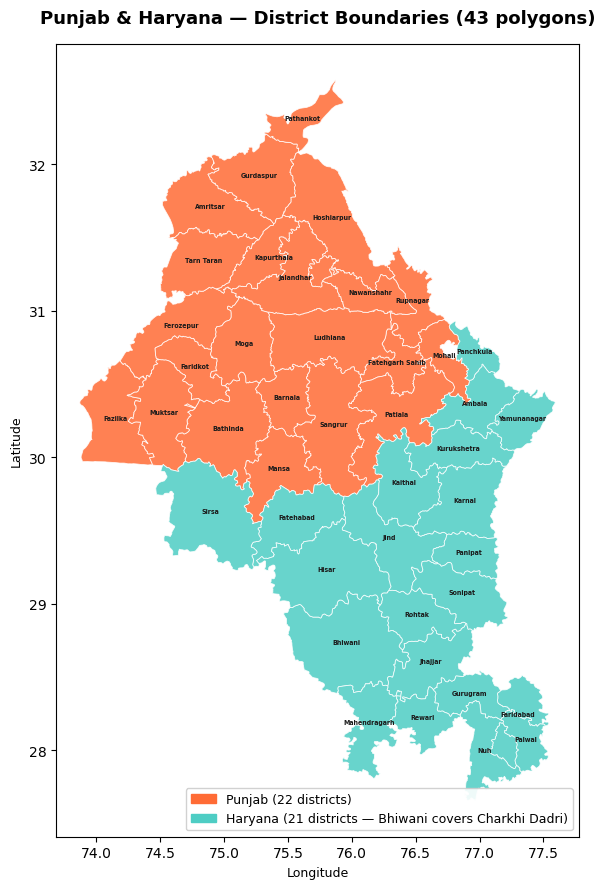

✅ Map saved: outputs/maps/00_district_boundaries.png


In [28]:
# District boundary map 
fig, ax = plt.subplots(figsize=(10, 9))

ph[ph['NAME_1'] == 'Punjab'].plot(
    ax=ax, color='#FF6B35', edgecolor='white', linewidth=0.6, alpha=0.85
)
ph[ph['NAME_1'] == 'Haryana'].plot(
    ax=ax, color='#4ECDC4', edgecolor='white', linewidth=0.6, alpha=0.85
)

# Label each district at its centroid
for _, row in ph.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row['NAME_2'], xy=(c.x, c.y),
        fontsize=4.5, ha='center', fontweight='bold', color='#1a1a1a'
    )

patches = [
    mpatches.Patch(color='#FF6B35', label='Punjab (22 districts)'),
    mpatches.Patch(color='#4ECDC4', label='Haryana (21 districts — Bhiwani covers Charkhi Dadri)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.9)
ax.set_title('Punjab & Haryana — District Boundaries (43 polygons)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)

plt.tight_layout()
plt.savefig('../Outputs/Maps/00_district_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved: outputs/maps/00_district_boundaries.png")
